# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [ ]:
# Import and mount google drive, if running locally comment out
from google.colab import drive
drive.mount('/content/drive')

# Imports
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# For colab, change if running locally
PROJECT_DIRECTORY = '/content/drive/MyDrive/RAT-Net_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data_splits/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "trained_model.pth"
TEMP_MODEL_DIRECTORY = PROJECT_DIRECTORY + "temp_model.pth"

# Create a Dataset object to be used later for training and testing
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Mounted at /content/drive


## Load preprocessed data splits

In [48]:
try:
  X_train = np.load(DATA_DIRECTORY + "X_train.npy")
  X_test = np.load(DATA_DIRECTORY + "X_test.npy")
  X_val = np.load(DATA_DIRECTORY + "X_val.npy")
  y_train = np.load(DATA_DIRECTORY + "y_train.npy")
  y_test = np.load(DATA_DIRECTORY + "y_test.npy")
  y_val = np.load(DATA_DIRECTORY + "y_val.npy")
except:
  print("Error loading data splits")

print("Class distribution:")
unique_classes_resampled, counts_resampled = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_classes_resampled, counts_resampled):
    print(f"Class {cls}: {count} samples")

Class distribution:
Class 0: 50000 samples
Class 1: 49999 samples
Class 2: 50000 samples
Class 3: 50000 samples
Class 4: 50000 samples


## Model

In [65]:
class ChannelAttention(nn.Module):
    """
    Channel attention for 1D feature maps.
    A forward pass applies attention weights based on global average and max pooling
    to the channel dimension of input x
    """
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pool over temporal dimension
        avg_pool = torch.mean(x, dim=-1)
        max_pool, _ = torch.max(x, dim=-1)

        # Shared MLP for both pooled outputs with sigmoid activation
        channel_attention = self.sigmoid(self.fc2(self.fc1(avg_pool)) + self.fc2(self.fc1(max_pool)))

        # Reshape attention to match x shape and return attention applied to input
        return x * channel_attention.unsqueeze(-1)

class SpatialAttention(nn.Module):
    """
    Spatial Attention for 1D feature maps. This means it is technically temporal attention
    A forward pass applies attention weights based on global and max pooling
    to the spatial dimension of input x
    """
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv1d(in_channels=2 , out_channels=1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pool across channel dimension
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)

        # Concatenate pooled features and apply convolution
        x_att = torch.cat([avg_pool, max_pool], dim=1)
        x_att = self.sigmoid(self.conv(x_att))

        # Return input with attention applied
        return x * x_att

class CBAMBlock(nn.Module):
    """
    Convolutional Block Attention Module for 1D data.
    A forward pass applies both channel and spatial attention to x
    """
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

class ResidualBlock1D(nn.Module):
    """
    1D Residual Block with CBAM and optional downsampling via stride
    Returns the output of the residual block after x has been passed through
    """
    def __init__(self, in_channels, out_channels, kernel_size=21, downsample=False, dropout=0.2):
        super(ResidualBlock1D, self).__init__()
        # Initailise convolution parameters
        stride = 2 if downsample else 1
        padding = (kernel_size - 1) // 2

        # Main convolution block
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Attention module
        self.cbam = CBAMBlock(out_channels)

        # Regularisation
        self.dropout = nn.Dropout(dropout)

        # Downsampling for identitiy connection
        self.downsample = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        # Create identity
        identity = self.downsample(x)

        # Convolutional block
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        # Attention and regularisation
        x = self.cbam(x)
        x = self.dropout(x)

        # Residual Connection
        x += identity
        return self.relu(x)

class PositionalEncoding(nn.Module):
    """
    Positional Encoding for 1D data, for the transformer.
    Encodes the position of each element.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        # Positional Encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine and cosine to even and odd indices of the encoding
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add dimension for batch combatibility
        pe = pe.unsqueeze(1)

        # Register buffer for positional encoding
        self.register_buffer('pe', pe)

    def forward(self, x):
        # This applies positional encoding to the input
        x = x + self.pe[:x.size(0)]
        return x

class ResNet1D(nn.Module):
    """
    1D ResNet module CBAM attention
    Returns feature map of input x
    """
    def __init__(self, num_blocks=4, kernel_size=21, dropout=0.2):
        super(ResNet1D, self).__init__()
        # Initialisation
        layers = []
        in_channels = 2 # Assume 2 input channels
        out_channels = 16 # Starting feature size
        current_size = 300 # Expected input size

        # Create residual blocks and calculate output size
        for i in range(num_blocks):
            # Apply downsampling in all but the last block
            downsample = i < num_blocks - 1
            layers.append(ResidualBlock1D(
                    in_channels, out_channels, kernel_size=kernel_size,
                    downsample=downsample, dropout=dropout)
                )

            # Update channel sizes for next block
            in_channels = out_channels
            out_channels *= 2

            # Update sequence length estimate if downsampling
            if i > 0:
                current_size = (current_size - kernel_size + 2) // 2 + 1

        self.ResNet = nn.Sequential(*layers)

    def forward(self, x):
        x = self.ResNet(x)
        return x

class Transformer(nn.Module):
    """
    Transformer encoder module for 1D data.
    Applies positional encoding and then multi-layer self-attention.
    """
    def __init__(self, d_model=128, nhead=4, num_layers=1, dropout=0.2):
        super(Transformer, self).__init__()
        # Create encoder layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, norm_first=True)
        # Create transformer
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.position_encoding = PositionalEncoding(d_model)

    def forward(self, x):
        # Apply positional encoding and then pass therough transformer encoder
        x = self.position_encoding(x)
        return self.transformer_encoder(x)

class Classifier(nn.Module):
    """
    Fully connected classifier with configurable hidden layers.
    """
    def __init__(self, input_dim=128, hidden_layers=[128], num_classes=5, dropout=0.2):
        super(Classifier, self).__init__()
        layers = []

        # Add hidden layers
        for hidden_dim in hidden_layers:
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            input_dim = hidden_dim

        # Handle output layer
        layers.append(nn.Linear(input_dim, num_classes))

        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x)

class RATNet(nn.Module):
    """
    Residual-Attention Transformer Network (RAT-Net) for classifying ECG data
    """
    def __init__(self, num_classes=5, dropout=0.2):
        super(RATNet, self).__init__()
        # Feature extraction using ResNet (Input assumed to be 300)
        self.ResNet = ResNet1D(dropout=dropout)
        # Transformer Encoder
        self.transformer = Transformer(dropout=dropout)
        # MLP classifier
        self.classifier = Classifier(num_classes=5, dropout=dropout)

    def forward(self, x):
        x = self.ResNet(x)          # [B,C,T]
        x = x.permute(2,0,1)        # [T,B,C]
        x = self.transformer(x)     # [T,B,C]
        x = x.mean(dim=0)           # [B,C]
        x = self.classifier(x)      # [B, num_classes]
        return x

## Training

### Training Parameters

In [51]:
# Move to GPU if possible
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

# Hyperparameters
epochs = 50
batch_size = 32
learning_rate = 4.688744856082865e-05
weight_decay = 0.000978293008700263
dropout_rate = 0.18551505006954347

# Datasets
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)
validation_dataset = ECGDataset(X_val, y_val)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Initialisation
model = RATNet(dropout=dropout_rate).to(device)
optimiser = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

cuda


### Training loop

In [52]:
best_val_f1 = 0.0
for epoch in range(epochs):
    # ---------------------- Training phase
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # ---------------------- Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), TEMP_MODEL_DIRECTORY)
        print("Best model updated.")

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - "
            f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
            f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} - Val F1 {val_f1}")


Best model updated.
Epoch 1/30 - Train Loss: 0.1401 - Train Acc: 0.9510 - Val Loss: 0.0948 - Val Acc: 0.9697 - Val F1 0.8487810202363573
Best model updated.
Epoch 2/30 - Train Loss: 0.0403 - Train Acc: 0.9864 - Val Loss: 0.0698 - Val Acc: 0.9785 - Val F1 0.876163165359262
Best model updated.
Epoch 3/30 - Train Loss: 0.0270 - Train Acc: 0.9912 - Val Loss: 0.0680 - Val Acc: 0.9818 - Val F1 0.9019616875089655
Epoch 4/30 - Train Loss: 0.0217 - Train Acc: 0.9929 - Val Loss: 0.0618 - Val Acc: 0.9842 - Val F1 0.9000992684007831
Best model updated.
Epoch 5/30 - Train Loss: 0.0175 - Train Acc: 0.9943 - Val Loss: 0.0564 - Val Acc: 0.9863 - Val F1 0.9282385303325398
Best model updated.
Epoch 6/30 - Train Loss: 0.0148 - Train Acc: 0.9953 - Val Loss: 0.0505 - Val Acc: 0.9898 - Val F1 0.9420872512926156
Epoch 7/30 - Train Loss: 0.0131 - Train Acc: 0.9959 - Val Loss: 0.0511 - Val Acc: 0.9890 - Val F1 0.936095014304502
Epoch 8/30 - Train Loss: 0.0118 - Train Acc: 0.9963 - Val Loss: 0.0584 - Val Acc: 0

## Testing

Test Accuracy:     99.27%
Test Precision:    95.75%
Test Recall:       95.24%
Test F1 Score:     95.50%

Per-Class Metrics:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00     18119
           S       0.94      0.92      0.93       556
           V       0.98      0.98      0.98      1447
           F       0.88      0.87      0.87       160
           Q       1.00      1.00      1.00      1608

    accuracy                           0.99     21890
   macro avg       0.96      0.95      0.95     21890
weighted avg       0.99      0.99      0.99     21890


Confusion Matrix (Test):


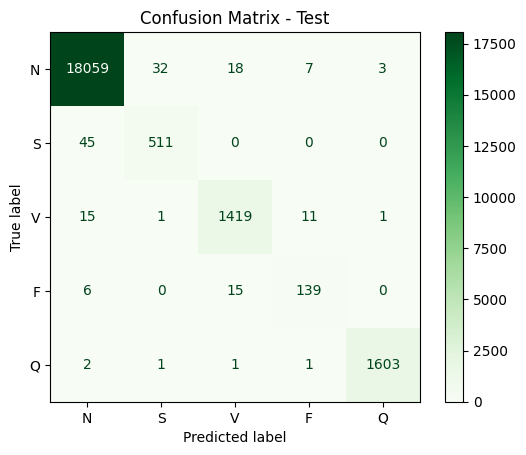

In [71]:
# Load best model
model2 = RATNet(dropout=dropout_rate)
model2.load_state_dict(torch.load(MODEL_DIRECTORY, map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")))
model2.to(device)

# Evaluation mode
model2.eval()
all_preds = []
all_labels = []

# Run model on testing data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model2(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Overall Metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"Test Accuracy:     {acc * 100:.2f}%")
print(f"Test Precision:    {precision * 100:.2f}%")
print(f"Test Recall:       {recall * 100:.2f}%")
print(f"Test F1 Score:     {f1 * 100:.2f}%")

# Per-class metrics
class_names = ['N', 'S', 'V', 'F', 'Q']
print("\nPer-Class Metrics:")
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
print("\nConfusion Matrix (Test):")
cm_test = confusion_matrix(all_labels, all_preds)
cm_test_disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
cm_test_disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Test")
plt.show()


In [72]:
# Corrected per-class F1 scores using average=None
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

print("\nPer-Class F1 Scores (4 Significant Figures):")
for i, f1_val in enumerate(per_class_f1):
    print(f"{class_names[i]}: F1 Score = {f1_val * 100:.4g}%")

# Calculate per-class accuracy
cm = confusion_matrix(all_labels, all_preds)

# Per-class accuracy is TP for class i / Total samples for class i
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy (4 Significant Figures):")
for i, accuracy_val in enumerate(per_class_accuracy):
    print(f"{class_names[i]}: Accuracy = {accuracy_val * 100:.4g}%")



Per-Class F1 Scores (4 Significant Figures):
N: F1 Score = 99.65%
S: F1 Score = 92.82%
V: F1 Score = 97.86%
F: F1 Score = 87.42%
Q: F1 Score = 99.72%

Per-Class Accuracy (4 Significant Figures):
N: Accuracy = 99.67%
S: Accuracy = 91.91%
V: Accuracy = 98.06%
F: Accuracy = 86.88%
Q: Accuracy = 99.69%


## Optionally save model

In [62]:
# torch.save(model.state_dict(), MODEL_DIRECTORY)

## Optuna Testing

In [ ]:
# lr = 1e-4
# batch_size = 128

# if torch.cuda.is_available():
#     device = torch.device("cuda")
# else:
#     device = torch.device("cpu")

# print(device)


# train_dataset = ECGDataset(X_train, y_train)
# test_dataset = ECGDataset(X_test, y_test)
# validation_dataset = ECGDataset(X_val, y_val)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# def test_model_configurations(train_loader, validation_loader, device, epochs=10):
#     # Define the different configurations to test
#     config_options = [
#         (3, 15), (3, 21), (3, 25), (3, 31),
#         (4, 15), (4, 21), (4, 25), (4, 31),
#         (5, 15), (5, 21), (5, 25), (5, 31),
#         (6, 15), (6, 21), (6, 25), (6, 31)

#     ]

#     # Store F1 scores for each configuration
#     f1_scores = {}

#     for num_blocks, kernel_size in config_options:
#         print(f"Testing configuration: {num_blocks} blocks, kernel size {kernel_size}")

#         # Initialize the model with the current configuration
#         model = RATNet(num_classes=5, dropout=0.2)

#         model.ResNet = ResNet1D(num_blocks=num_blocks, kernel_size=kernel_size, dropout=0.2)

#         if num_blocks == 2:
#             model.transformer = Transformer(d_model=64, nhead=4, num_layers=1, dropout=0.2)
#             model.classifier = Classifier(shape=[64, 128, 5], dropout=0.2)
#         if num_blocks == 3:
#             model.transformer = Transformer(d_model=128, nhead=4, num_layers=1, dropout=0.2)
#             model.classifier = Classifier(shape=[128, 128, 5], dropout=0.2)
#         if num_blocks == 4:
#             model.transformer = Transformer(d_model=256, nhead=4, num_layers=1, dropout=0.2)
#             model.classifier = Classifier(shape=[256, 128, 5], dropout=0.2)
#         if num_blocks == 5:
#             model.transformer = Transformer(d_model=512, nhead=4, num_layers=1, dropout=0.2)
#             model.classifier = Classifier(shape=[512, 128, 5], dropout=0.2)
#         if num_blocks == 6:
#             model.transformer = Transformer(d_model=1024, nhead=4, num_layers=1, dropout=0.2)
#             model.classifier = Classifier(shape=[1024, 128, 5], dropout=0.2)

#         model.to(device)  # Ensure the model is on the correct device

#         optimiser = torch.optim.Adam(model.parameters(), lr=lr)
#         criterion = nn.CrossEntropyLoss()

#         # Training phase
#         for epoch in range(epochs):
#             model.train()
#             total_loss, correct, total = 0, 0, 0

#             for inputs, labels in train_loader:
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)

#                 optimiser.zero_grad()
#                 outputs = model(inputs)

#                 loss = criterion(outputs, labels)
#                 loss.backward()
#                 optimiser.step()

#                 total_loss += loss.item() * inputs.size(0)
#                 _, predicted = torch.max(outputs, 1)
#                 correct += (predicted == labels).sum().item()
#                 total += labels.size(0)

#             train_loss = total_loss / total
#             train_acc = correct / total

#         # Validation phase
#         model.eval()
#         val_loss, val_correct, val_total = 0, 0, 0
#         all_preds = []
#         all_labels = []

#         with torch.no_grad():
#             for inputs, labels in validation_loader:
#                 inputs = inputs.to(device)
#                 labels = labels.to(device)

#                 outputs = model(inputs)
#                 loss = criterion(outputs, labels)

#                 val_loss += loss.item() * inputs.size(0)
#                 _, predicted = torch.max(outputs, 1)
#                 val_correct += (predicted == labels).sum().item()
#                 val_total += labels.size(0)

#                 all_preds.extend(predicted.cpu().numpy())
#                 all_labels.extend(labels.cpu().numpy())

#         val_loss = val_loss / val_total
#         val_acc = val_correct / val_total

#         # Calculate F1 score
#         f1 = f1_score(all_labels, all_preds, average="macro")
#         f1_scores[(num_blocks, kernel_size)] = f1

#         print(f"Configuration: {num_blocks} blocks, kernel size {kernel_size} - "
#               f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} - F1 Score: {f1:.4f}")

#     return f1_scores

# def plot_f1_scores(f1_scores):
#     """
#     f1_scores: dictionary where keys are (num_blocks, kernel_size) and values are F1 scores
#     """

#     # Organize scores by number of blocks
#     blocks_data = {}

#     for (num_blocks, kernel_size), f1 in f1_scores.items():
#         if num_blocks not in blocks_data:
#             blocks_data[num_blocks] = {'kernel_sizes': [], 'f1_scores': []}
#         blocks_data[num_blocks]['kernel_sizes'].append(kernel_size)
#         blocks_data[num_blocks]['f1_scores'].append(f1)

#     # Plot
#     plt.figure(figsize=(10, 6))

#     for num_blocks, data in sorted(blocks_data.items()):
#         # Sort by kernel size
#         sorted_data = sorted(zip(data['kernel_sizes'], data['f1_scores']))
#         kernel_sizes, f1s = zip(*sorted_data)

#         plt.plot(kernel_sizes, f1s, marker='o', label=f"{num_blocks} Blocks")

#     plt.title('F1 Score vs Kernel Size')
#     plt.xlabel('Kernel Size')
#     plt.ylabel('F1 Score')
#     plt.legend(title="Number of Blocks")
#     plt.grid(True)
#     plt.xticks([15, 21, 25, 31])  # Since your kernel sizes are these
#     plt.ylim(0.9, 0.97)
#     plt.show()

# f1_scores = test_model_configurations(train_loader, validation_loader, device, epochs=10)

# plot_f1_scores(f1_scores)